# L5 companion 2 · Optimizer state, trajectories, and PyTorch

We keep one loss and one starting point fixed:

$$L(x,y)=x^2+50y^2, \qquad \nabla L(x,y)=(2x,100y).$$

This ravine is shallow along $x$ and steep along $y$. We will inspect not only the final curve, but the **state** that produces each update:

- momentum: first moment $m_t$;
- AdaGrad: cumulative squared-gradient state $G_t$;
- RMSProp: recent squared-gradient moment $v_t$;
- Adam: both moments plus bias correction.

The experiment is deterministic and deliberately tiny. It is a microscope for mechanisms, not a benchmark ranking.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True)
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

START = np.array([-2.4, 0.85], dtype=float)

def loss(theta):
    x, y = theta
    return x**2 + 50.0*y**2

def grad(theta):
    x, y = theta
    return np.array([2.0*x, 100.0*y])

print("start =", START)
print("gradient at start =", grad(START))
print("loss at start =", loss(START))

start = [-2.4   0.85]
gradient at start = [-4.8 85. ]
loss at start = 41.88499999999999


## 1 · Reproduce the lecture's dense/rare stream

We first use exactly the lecture sequence

$$g_1=(4,0),\qquad g_2=(4,0),\qquad g_3=(4,0.4).$$

The first coordinate is active on every minibatch; the second is rare. Before running the next cell, predict the step-3 normalized update under AdaGrad, RMSProp, and Adam. Which method remembers all squared gradients, which forgets old evidence, and which also remembers direction?

In [2]:
stream = np.array([[4.0, 0.0], [4.0, 0.0], [4.0, 0.4]])
rho, beta1, beta2, eps = 0.9, 0.9, 0.999, 1e-8

G = np.zeros(2)       # AdaGrad: all squared gradients
v_rms = np.zeros(2)   # RMSProp: recent squared gradients
m_adam = np.zeros(2)  # Adam: direction
v_adam = np.zeros(2)  # Adam: scale

print(' t       g_t          AdaGrad dir      RMSProp dir       Adam dir')
for t, g in enumerate(stream, start=1):
    G += g**2
    v_rms = rho * v_rms + (1 - rho) * g**2
    m_adam = beta1 * m_adam + (1 - beta1) * g
    v_adam = beta2 * v_adam + (1 - beta2) * g**2
    mhat = m_adam / (1 - beta1**t)
    vhat = v_adam / (1 - beta2**t)
    adagrad_dir = np.divide(g, np.sqrt(G) + eps)
    rmsprop_dir = np.divide(g, np.sqrt(v_rms) + eps)
    adam_dir = np.divide(mhat, np.sqrt(vhat) + eps)
    print(f'{t:2d}  {g!s:14s} {adagrad_dir!s:16s} {rmsprop_dir!s:17s} {adam_dir}')

assert np.allclose(adagrad_dir, [1/np.sqrt(3), 1.0])
assert np.allclose(rmsprop_dir, [1.920947, np.sqrt(10)], atol=1e-6)
assert np.allclose(adam_dir, [1.0, 0.638814], atol=1e-6)

 t       g_t          AdaGrad dir      RMSProp dir       Adam dir
 1  [4. 0.]        [1. 0.]          [3.162278 0.      ] [1. 0.]
 2  [4. 0.]        [0.707107 0.      ] [2.294157 0.      ] [1. 0.]
 3  [4.  0.4]      [0.57735 1.     ] [1.920947 3.162277] [1.       0.638814]


## 2 · Predict and calculate the first ravine state

At the start, $g_1=(-4.8,85)$. Before running the next cell, calculate:

1. normalized momentum with $\beta=0.9$: $m_1=0.9m_0+0.1g_1$;
2. AdaGrad: $G_1=g_1^2$ and $g_1/\sqrt{G_1}$;
3. RMSProp with $\rho=0.9$: $v_1=0.9v_0+0.1g_1^2$ and $g_1/\sqrt{v_1}$;
4. Adam's bias-corrected $\hat m_1$ and $\hat v_1$ with $\beta_1=0.9$, $\beta_2=0.999$.

Predict which first update uses the raw $85/4.8$ coordinate imbalance and which updates normalize it away.

In [3]:
g1 = grad(START)
beta, rho, beta1, beta2 = 0.9, 0.9, 0.9, 0.999
eps = 1e-8

m1_momentum = (1 - beta) * g1
G1_adagrad = g1**2
adagrad_normalized = g1 / (np.sqrt(G1_adagrad) + eps)
v1_rmsprop = (1 - rho) * g1**2
rms_normalized = g1 / (np.sqrt(v1_rmsprop) + eps)

m1_adam = (1 - beta1) * g1
v1_adam = (1 - beta2) * g1**2
mhat1 = m1_adam / (1 - beta1)
vhat1 = v1_adam / (1 - beta2)
adam_normalized = mhat1 / (np.sqrt(vhat1) + eps)

print("g1                         =", g1)
print("momentum m1                =", m1_momentum)
print("AdaGrad G1                 =", G1_adagrad)
print("AdaGrad normalized gradient=", adagrad_normalized)
print("RMSProp v1                 =", v1_rmsprop)
print("RMSProp normalized gradient=", rms_normalized)
print("Adam mhat1                 =", mhat1)
print("Adam vhat1                 =", vhat1)
print("Adam normalized direction  =", adam_normalized)

assert np.allclose(mhat1, g1)
assert np.allclose(vhat1, g1**2)
assert np.allclose(np.abs(adam_normalized), 1.0)

g1                         = [-4.8 85. ]
momentum m1                = [-0.48  8.5 ]
AdaGrad G1                 = [  23.04 7225.  ]
AdaGrad normalized gradient= [-1.  1.]
RMSProp v1                 = [  2.304 722.5  ]
RMSProp normalized gradient= [-3.162278  3.162278]
Adam mhat1                 = [-4.8 85. ]
Adam vhat1                 = [  23.04 7225.  ]
Adam normalized direction  = [-1.  1.]


## 3 · Implement the five update rules from scratch

The learning rates below are **method-specific** so that every path is visible on one figure. Do not compare their numeric values as if the update vectors had the same scale. This from-scratch implementation uses normalized momentum, $m_t=\beta m_{t-1}+(1-\beta)g_t$, with $\eta=0.060$. PyTorch uses the unnormalized buffer $u_t=\beta u_{t-1}+g_t$; its equivalent rate is $0.060(1-\beta)=0.006$.

As you read the function, identify exactly where each state tensor is created and updated.

In [4]:
def optimize(name, steps=80):
    theta = START.copy()
    m = np.zeros_like(theta)
    v = np.zeros_like(theta)
    G = np.zeros_like(theta)
    path, losses, states, updates = [theta.copy()], [loss(theta)], [], []

    config = {
        "GD":       dict(lr=0.014),
        "Momentum": dict(lr=0.060, beta=0.9),
        "AdaGrad":  dict(lr=0.10),
        "RMSProp":  dict(lr=0.06, rho=0.9),
        "Adam":     dict(lr=0.10, beta1=0.9, beta2=0.999),
    }[name]

    for t in range(1, steps + 1):
        g = grad(theta)
        if name == "GD":
            update = g
        elif name == "Momentum":
            m = config["beta"] * m + (1 - config["beta"]) * g
            update = m
        elif name == "AdaGrad":
            G = G + g**2
            update = g / (np.sqrt(G) + 1e-8)
        elif name == "RMSProp":
            v = config["rho"] * v + (1 - config["rho"]) * g**2
            update = g / (np.sqrt(v) + 1e-8)
        elif name == "Adam":
            m = config["beta1"] * m + (1 - config["beta1"]) * g
            v = config["beta2"] * v + (1 - config["beta2"]) * g**2
            mhat = m / (1 - config["beta1"]**t)
            vhat = v / (1 - config["beta2"]**t)
            update = mhat / (np.sqrt(vhat) + 1e-8)

        delta = -config["lr"] * update
        theta = theta + delta
        path.append(theta.copy())
        losses.append(loss(theta))
        states.append({"m": m.copy(), "v": v.copy(), "G": G.copy()})
        updates.append(delta.copy())

    return {
        "path": np.asarray(path),
        "loss": np.asarray(losses),
        "state": states,
        "update": np.asarray(updates),
        "config": config,
    }

names = ["GD", "Momentum", "AdaGrad", "RMSProp", "Adam"]
runs = {name: optimize(name) for name in names}
for name in names:
    print(f"{name:8s}: final theta={runs[name]['path'][-1]}, final loss={runs[name]['loss'][-1]:.3e}")

GD      : final theta=[-0.247464  0.      ], final loss=6.124e-02
Momentum: final theta=[-0.013012 -0.012558], final loss=8.054e-03
AdaGrad : final theta=[-1.006941  0.018581], final loss=1.031e+00
RMSProp : final theta=[-0.  0.], final loss=9.061e-17
Adam    : final theta=[-0.039036 -0.010677], final loss=7.224e-03


### Predict before plotting

Sketch five rough paths from the common start to the origin. Which path should:

- zigzag most strongly across the ravine?
- smooth alternating $y$ gradients but retain progress in $x$?
- take nearly equal normalized coordinate steps at the beginning under both AdaGrad and RMSProp?
- combine that normalization with a smoothed direction?

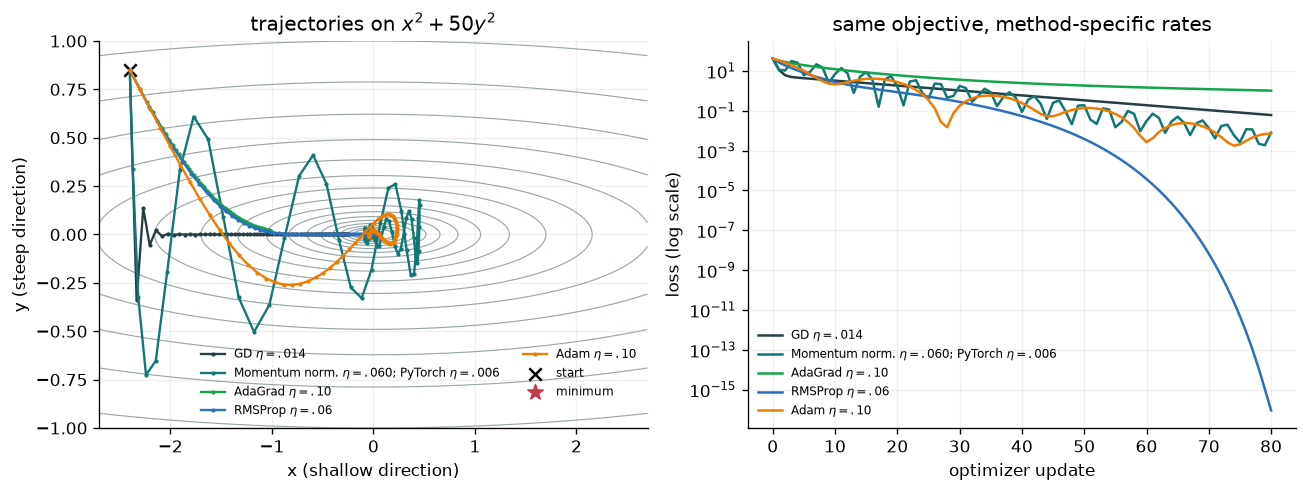

In [5]:
colors = {"GD": "#263f44", "Momentum": "#0f7775", "AdaGrad": "#14a44d", "RMSProp": "#2c6fbb", "Adam": "#ef7c00"}
method_labels = {
    "GD": r"GD $\eta=.014$",
    "Momentum": r"Momentum norm. $\eta=.060$; PyTorch $\eta=.006$",
    "AdaGrad": r"AdaGrad $\eta=.10$",
    "RMSProp": r"RMSProp $\eta=.06$",
    "Adam": r"Adam $\eta=.10$",
}
gx, gy = np.meshgrid(np.linspace(-2.7, 2.7, 320), np.linspace(-1.0, 1.0, 260))
surface = gx**2 + 50*gy**2

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].contour(gx, gy, surface, levels=np.geomspace(0.04, 50, 16), colors="#9aa7a9", linewidths=0.7)
for name in names:
    path = runs[name]["path"]
    axes[0].plot(path[:, 0], path[:, 1], ".-", ms=3, lw=1.4, color=colors[name], label=method_labels[name])
axes[0].scatter(*START, color="black", marker="x", s=55, label="start")
axes[0].scatter(0, 0, color="#c23b45", marker="*", s=90, label="minimum")
axes[0].set(xlabel="x (shallow direction)", ylabel="y (steep direction)", title=r"trajectories on $x^2+50y^2$")
axes[0].legend(frameon=False, fontsize=7, ncol=2)

for name in names:
    axes[1].semilogy(runs[name]["loss"], color=colors[name], label=method_labels[name])
axes[1].set(xlabel="optimizer update", ylabel="loss (log scale)", title="same objective, method-specific rates")
axes[1].legend(frameon=False, fontsize=7)
for ax in axes:
    ax.grid(alpha=0.18)
fig.tight_layout()
plt.show()

## 4 · Inspect the state, not only the trajectory

A path can look smooth for different reasons. The next two plots expose both the actual parameter updates and the stored state that caused them.

Predict what happens to the $y$ component of momentum when the raw $y$ gradient repeatedly changes sign. Then predict why AdaGrad's $G_y$ and RMSProp's $v_y$ are much larger than their $x$ components—and why only one of those memories can decrease relative to older evidence.

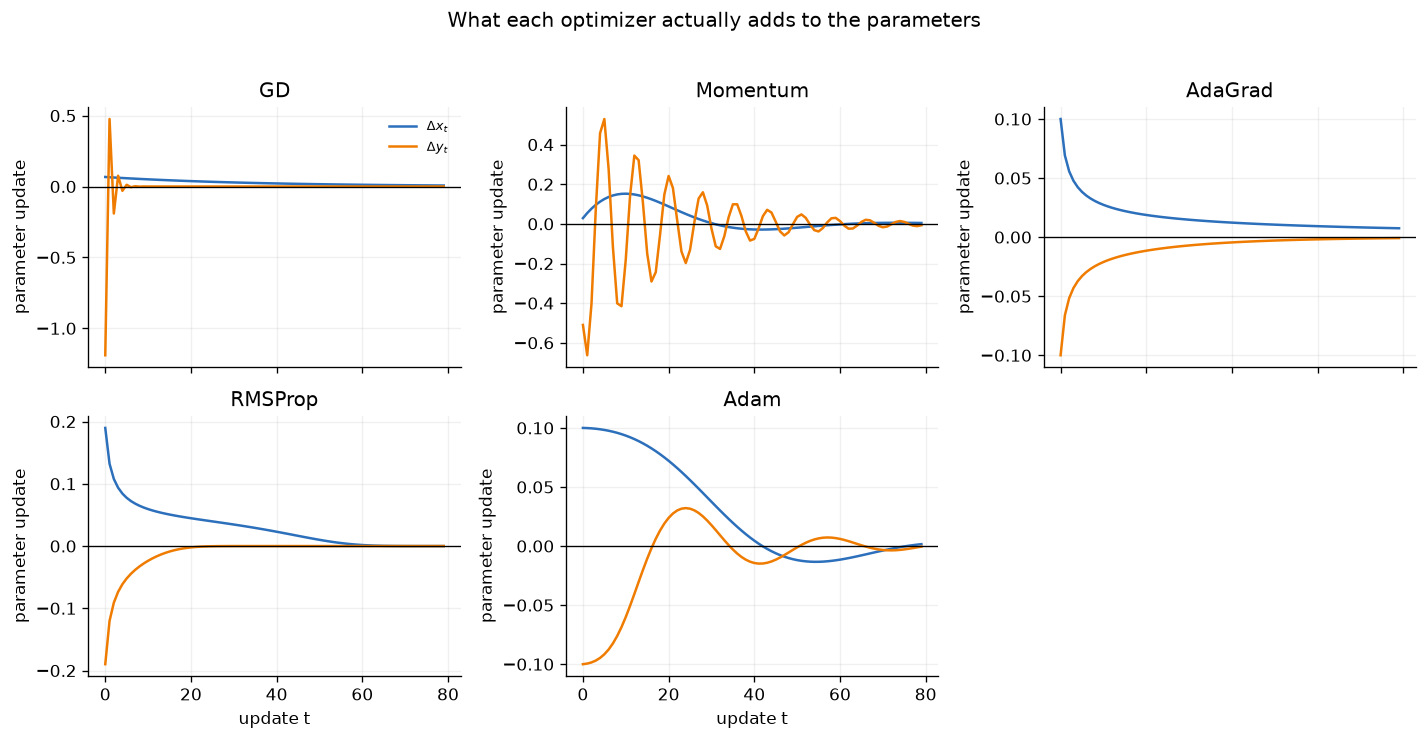

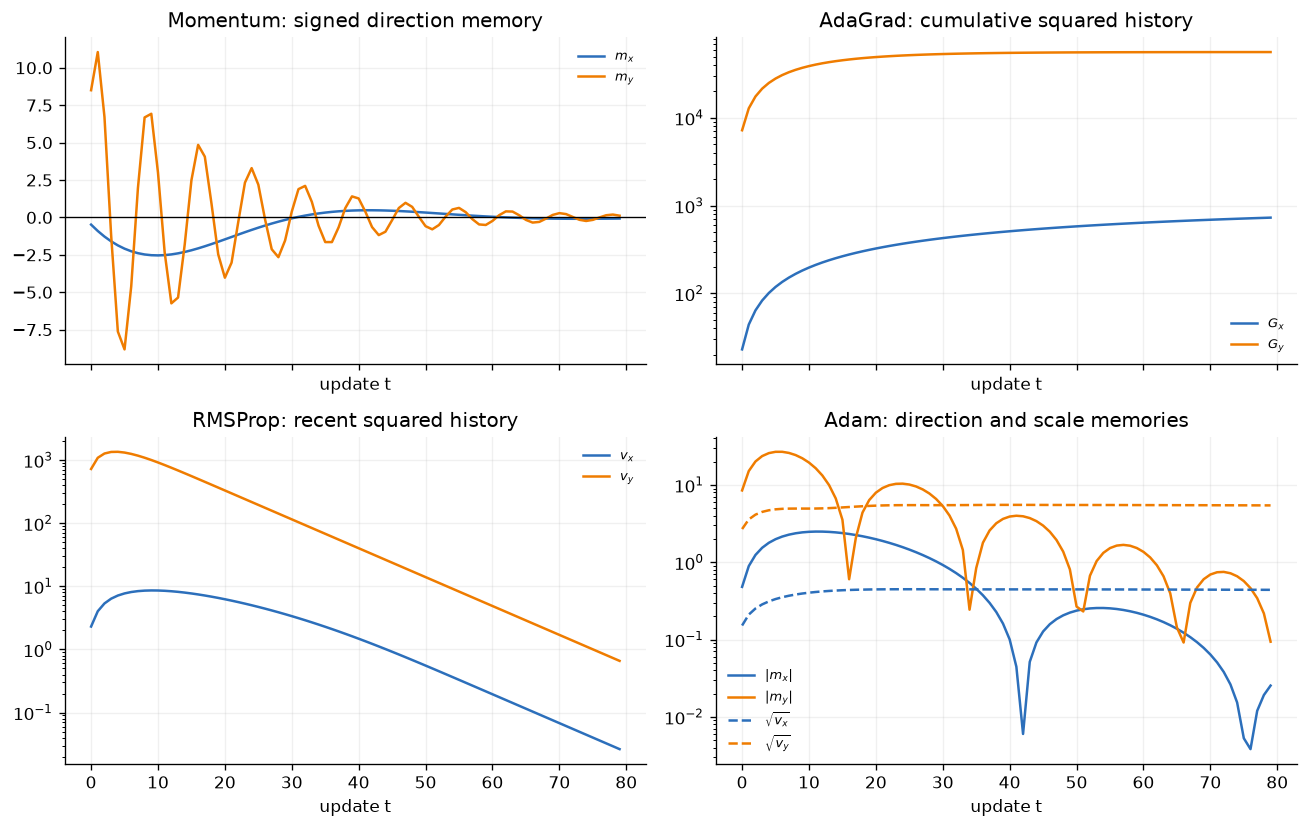

RMSProp v1 = [  2.304 722.5  ]
Adam raw m1 = [-0.48  8.5 ]
Adam raw v1 = [0.02304 7.225  ]


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=True)
for ax, name in zip(axes.flat, names):
    updates = runs[name]["update"]
    ax.plot(updates[:, 0], color="#2c6fbb", label=r"$\Delta x_t$")
    ax.plot(updates[:, 1], color="#ef7c00", label=r"$\Delta y_t$")
    ax.axhline(0, color="black", lw=0.8)
    ax.set_title(name)
    ax.set_ylabel("parameter update")
    ax.grid(alpha=0.18)
axes.flat[-1].axis("off")
for ax in axes[1, :2]:
    ax.set_xlabel("update t")
axes[0, 0].legend(frameon=False, fontsize=8)
fig.suptitle("What each optimizer actually adds to the parameters", y=1.02)
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)

momentum_m = np.array([s["m"] for s in runs["Momentum"]["state"]])
axes[0, 0].plot(momentum_m[:, 0], label=r"$m_x$", color="#2c6fbb")
axes[0, 0].plot(momentum_m[:, 1], label=r"$m_y$", color="#ef7c00")
axes[0, 0].axhline(0, color="black", lw=0.8)
axes[0, 0].set_title("Momentum: signed direction memory")

adagrad_G = np.array([s["G"] for s in runs["AdaGrad"]["state"]])
axes[0, 1].semilogy(np.maximum(adagrad_G[:, 0], 1e-30), label=r"$G_x$", color="#2c6fbb")
axes[0, 1].semilogy(np.maximum(adagrad_G[:, 1], 1e-30), label=r"$G_y$", color="#ef7c00")
axes[0, 1].set_title("AdaGrad: cumulative squared history")

rms_v = np.array([s["v"] for s in runs["RMSProp"]["state"]])
axes[1, 0].semilogy(np.maximum(rms_v[:, 0], 1e-30), label=r"$v_x$", color="#2c6fbb")
axes[1, 0].semilogy(np.maximum(rms_v[:, 1], 1e-30), label=r"$v_y$", color="#ef7c00")
axes[1, 0].set_title("RMSProp: recent squared history")

adam_m = np.array([s["m"] for s in runs["Adam"]["state"]])
adam_v = np.array([s["v"] for s in runs["Adam"]["state"]])
axes[1, 1].semilogy(np.maximum(np.abs(adam_m[:, 0]), 1e-30), label=r"$|m_x|$", color="#2c6fbb")
axes[1, 1].semilogy(np.maximum(np.abs(adam_m[:, 1]), 1e-30), label=r"$|m_y|$", color="#ef7c00")
axes[1, 1].semilogy(np.maximum(np.sqrt(adam_v[:, 0]), 1e-30), "--", label=r"$\sqrt{v_x}$", color="#2c6fbb")
axes[1, 1].semilogy(np.maximum(np.sqrt(adam_v[:, 1]), 1e-30), "--", label=r"$\sqrt{v_y}$", color="#ef7c00")
axes[1, 1].set_title("Adam: direction and scale memories")

for ax in axes.flat:
    ax.grid(alpha=0.18)
    ax.legend(frameon=False, fontsize=8)
    ax.set_xlabel("update t")
fig.tight_layout()
plt.show()

print("RMSProp v1 =", rms_v[0])
print("Adam raw m1 =", adam_m[0])
print("Adam raw v1 =", adam_v[0])

## 5 · Diagnose a failure by changing one cause

Plain GD is stable on this quadratic only if its learning rate is small enough for the steep $y$ direction. Increase GD's rate from `0.014` to `0.021`, keeping everything else fixed.

Before running it, predict whether the trajectory will merely oscillate, remain bounded, or diverge. Then restore the rate.

Next, try clipping the raw gradient to global norm 10. Does clipping make an unstable learning rate a good learning rate, or does it only cap each dangerous step? Explain from the resulting path.

stable lr=0.014      max |theta|=2.546e+00  max loss=4.188e+01  final loss=7.890e-01
unstable lr=0.021    max |theta|=2.389e+01  max loss=2.853e+04  final loss=2.853e+04
same lr + clip=10    max |theta|=2.546e+00  max loss=4.188e+01  final loss=9.303e-01


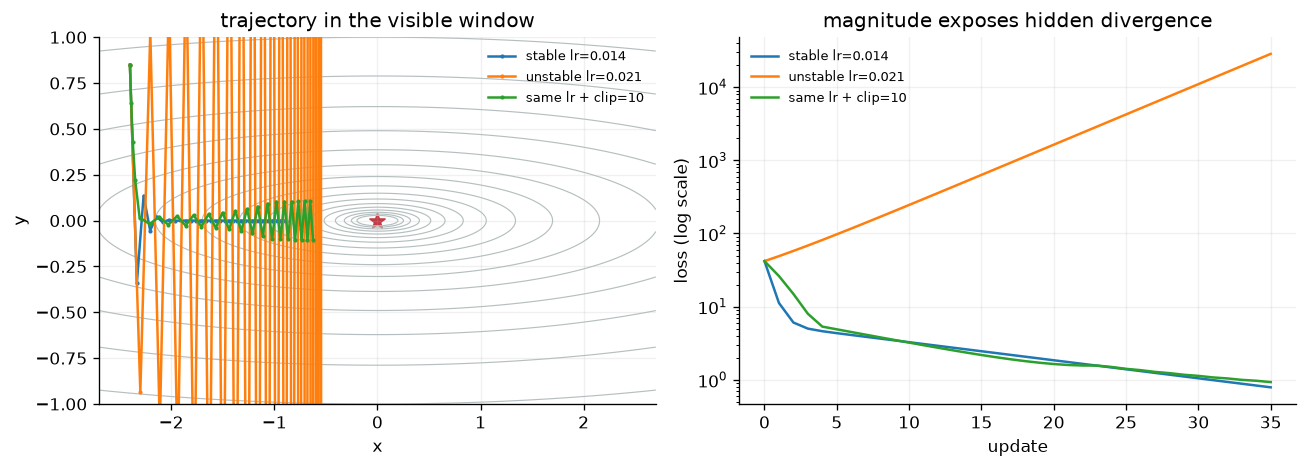

In [7]:
def run_gd_variant(lr, steps=35, clip_norm=None):
    theta = START.copy()
    path = [theta.copy()]
    for _ in range(steps):
        g = grad(theta)
        if clip_norm is not None and np.linalg.norm(g) > clip_norm:
            g = g * (clip_norm / np.linalg.norm(g))
        theta = theta - lr * g
        path.append(theta.copy())
    return np.asarray(path)

variants = {
    "stable lr=0.014": run_gd_variant(0.014),
    "unstable lr=0.021": run_gd_variant(0.021),
    "same lr + clip=10": run_gd_variant(0.021, clip_norm=10.0),
}

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].contour(gx, gy, surface, levels=np.geomspace(0.04, 50, 16), colors="#b5bfc0", linewidths=0.7)
for name, path in variants.items():
    values = np.array([loss(point) for point in path])
    axes[0].plot(path[:, 0], path[:, 1], ".-", ms=3, label=name)
    axes[1].semilogy(np.maximum(values, 1e-30), label=name)
    print(f'{name:20s} max |theta|={np.linalg.norm(path, axis=1).max():.3e}  max loss={values.max():.3e}  final loss={values[-1]:.3e}')
axes[0].scatter(0, 0, color="#c23b45", marker="*", s=90)
axes[0].set(xlim=(-2.7, 2.7), ylim=(-1.0, 1.0), xlabel="x", ylabel="y", title="trajectory in the visible window")
axes[1].set(xlabel="update", ylabel="loss (log scale)", title="magnitude exposes hidden divergence")
for ax in axes:
    ax.grid(alpha=0.18)
    ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

## 6 · Verify the mechanism with PyTorch

PyTorch uses the same gradients and state ideas, while handling tensor bookkeeping. We optimize a single two-element parameter tensor. The purpose is to inspect the API boundary:

1. `loss.backward()` fills `.grad`;
2. `optimizer.step()` consumes the gradient and stored state;
3. `zero_grad()` starts a new update window.

In [8]:
import torch

torch.manual_seed(0)

def run_torch(kind, steps=80):
    theta = torch.nn.Parameter(torch.tensor(START, dtype=torch.float64))
    if kind == "SGD":
        opt = torch.optim.SGD([theta], lr=0.014)
    elif kind == "Momentum":
        # PyTorch uses the unnormalized velocity-buffer convention.
        opt = torch.optim.SGD([theta], lr=0.006, momentum=0.9)
    elif kind == "AdaGrad":
        opt = torch.optim.Adagrad([theta], lr=0.10, eps=1e-8)
    elif kind == "RMSProp":
        opt = torch.optim.RMSprop([theta], lr=0.06, alpha=0.9, eps=1e-8)
    elif kind == "Adam":
        opt = torch.optim.Adam([theta], lr=0.10, betas=(0.9, 0.999), eps=1e-8)

    path, losses = [theta.detach().numpy().copy()], []
    first_grad = None
    for _ in range(steps):
        opt.zero_grad(set_to_none=True)
        objective = theta[0]**2 + 50.0*theta[1]**2
        objective.backward()
        if first_grad is None:
            first_grad = theta.grad.detach().numpy().copy()
        opt.step()
        path.append(theta.detach().numpy().copy())
        with torch.no_grad():
            post_step_loss = theta[0]**2 + 50.0*theta[1]**2
        losses.append(float(post_step_loss))

    raw_state = next(iter(opt.state.values()), {})
    tensor_state = {
        key: tuple(value.shape)
        for key, value in raw_state.items()
        if torch.is_tensor(value) and value.ndim > 0
    }
    return np.asarray(path), np.asarray(losses), first_grad, tensor_state

torch_runs = {name: run_torch(name if name != "GD" else "SGD") for name in names}
for name, (path, losses, first_grad, tensor_state) in torch_runs.items():
    print(f"{name:8s}: first grad={first_grad}, final post-step loss={losses[-1]:.3e}, state tensors={tensor_state}")

assert np.allclose(torch_runs["GD"][2], grad(START))

GD      : first grad=[-4.8 85. ], final post-step loss=6.124e-02, state tensors={}
Momentum: first grad=[-4.8 85. ], final post-step loss=8.054e-03, state tensors={'momentum_buffer': (2,)}
AdaGrad : first grad=[-4.8 85. ], final post-step loss=1.031e+00, state tensors={'sum': (2,)}
RMSProp : first grad=[-4.8 85. ], final post-step loss=9.061e-17, state tensors={'square_avg': (2,)}
Adam    : first grad=[-4.8 85. ], final post-step loss=7.224e-03, state tensors={'exp_avg': (2,), 'exp_avg_sq': (2,)}


## 7 · Explain the evidence

Write a short response to each prompt:

1. Which optimizer stores no parameter-sized state tensor, one, or two? Use the printed key/shape summaries; do not count scalar `step` bookkeeping as a state tensor.
2. AdaGrad and RMSProp both store squared gradients. Which state can forget old evidence, and where is that visible in the trace?
3. Momentum and RMSProp both reduce visible zigzagging. What different stored quantities cause that behaviour?
4. Why must optimizer comparisons report the learning-rate schedule, batch size, update count, and random seeds?
5. Why is this deterministic quadratic a good mechanism test but a poor basis for declaring a universally best optimizer?

### Takeaway

An optimizer is easiest to understand as **state plus a rule for turning that state into an update**. Trajectories show the consequence; state traces explain the cause.